In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


In [2]:

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names


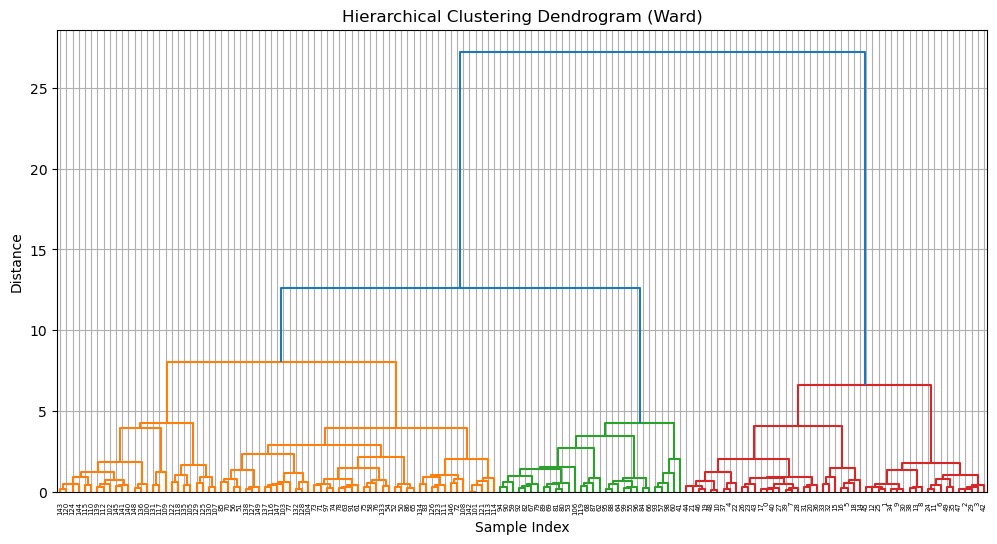


Silhouette Score: 0.447
Adjusted Rand Index (ARI) vs True Labels: 0.615


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [3]:

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 1: Compute linkage matrix
linked = linkage(X_scaled, method='ward')

# Step 2: Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=10)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

# Step 3: Create clusters using fcluster
n_clusters = 3
clusters_scipy = fcluster(linked, t=n_clusters, criterion='maxclust')

# Step 4: Agglomerative Clustering using sklearn (for comparison)
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
clusters_sklearn = agg.fit_predict(X_scaled)

# Step 5: Silhouette Score
silhouette = silhouette_score(X_scaled, clusters_sklearn)
print(f"\nSilhouette Score: {silhouette:.3f}")

# Step 6: Compare with true labels
ari = adjusted_rand_score(y, clusters_sklearn)
print(f"Adjusted Rand Index (ARI) vs True Labels: {ari:.3f}")

# Step 7: Visualize clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
df['True Label'] = y
df['Cluster (scikit-learn)'] = clusters_sklearn
df['Cluster (scipy)'] = clusters_scipy

# Step 8: Plot the clusters
plt.figure(figsize=(10, 5))


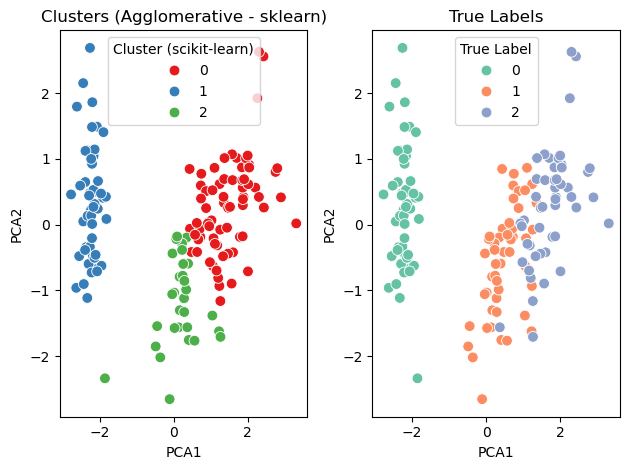

In [4]:

# Agglomerative Clustering clusters
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster (scikit-learn)", palette='Set1', s=60)
plt.title("Clusters (Agglomerative - sklearn)")

# True labels
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="True Label", palette='Set2', s=60)
plt.title("True Labels")

plt.tight_layout()
plt.show()
